# EDA Workshop — QuickMart Sales

**Dataset:** `datasets/new-raw/` — the QuickMart order history (orders,
order_items, products, customers). The raw files are dirty, so we clean first.

**Goal:** *Which categories, brands, and customer tiers drive the most revenue?*

---
### Steps
1. Load & Clean
2. Build the sales line-item table
3. Univariate Analysis (subtotal, qty)
4. Revenue by Category
5. Revenue by Brand
6. Category × Customer Tier
7. Unit Price vs Quantity
8. Key Findings


## โจทย์ — Workshop Questions

You are a data analyst at **QuickMart**. Using the raw order history, clean the
data and answer:

1. **Top category** — which *category* earns the most revenue?
2. **Brand dependence** — which *brand* do we depend on most by revenue?
3. **Best customers** — which *sub_tier* of customers spends the most?
4. **Distributions** — how are line-item subtotals and quantities spread out?
5. **Price vs quantity** — do pricier items sell in smaller quantities?


In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.float_format', '{:,.0f}'.format)
sns.set_theme(style='whitegrid')
%matplotlib inline

DATASETS = next(
    os.path.join(d, 'datasets')
    for d in ['.', '..', '../..', '../../..']
    if os.path.isdir(os.path.join(d, 'datasets'))
)
RAW = os.path.join(DATASETS, 'new-raw')
print('Setup complete')

Setup complete


## 1. Load & Clean

In [2]:
products    = pd.read_csv(os.path.join(RAW, 'products.csv'))
order_items = pd.read_csv(os.path.join(RAW, 'order_items.csv'))
orders      = pd.read_csv(os.path.join(RAW, 'orders.csv'), parse_dates=['order_date'])
customers   = pd.read_csv(os.path.join(RAW, 'customers.csv'))

products['category'] = products['category'].astype('string').str.strip()
products = products[products['category'].notna() & (products['category'] != '') & (products['price'] > 0)]
products = products.drop_duplicates(subset=['product_id'])

order_items = order_items.drop_duplicates().query('qty > 0 and unit_price > 0').copy()
order_items['subtotal'] = (order_items['qty'] * order_items['unit_price']).round(2)

orders = orders.drop_duplicates().drop_duplicates(subset=['order_id']).copy()
orders['status'] = orders['status'].str.strip().str.lower().replace({'canceled': 'cancelled'})
orders = orders.query('amount > 0')

customers = customers.drop_duplicates().drop_duplicates(subset=['customer_id']).copy()
customers = customers[customers['email'].astype('string').str.contains(r'@.+\.', regex=True, na=False)]
customers['sub_tier'] = customers['sub_tier'].str.strip().str.title()

print(f"clean -> products={len(products)}, order_items={len(order_items)}, "
      f"orders={len(orders)}, customers={len(customers)}")

clean -> products=50, order_items=9122, orders=2966, customers=984


## 2. Build the sales line-item table

In [3]:
sales = (
    order_items
    .merge(products[['product_id', 'product_name', 'category', 'brand']], on='product_id', how='inner')
    .merge(orders[['order_id', 'customer_id', 'order_date', 'status']], on='order_id', how='inner')
    .merge(customers[['customer_id', 'sub_tier']], on='customer_id', how='left')
)
sales['month'] = sales['order_date'].dt.strftime('%Y-%m')
print('sales shape:', sales.shape)
sales.head()

sales shape: (9024, 14)


,order_item_id,order_id,product_id,qty,unit_price,subtotal,product_name,category,brand,customer_id,order_date,status,sub_tier,month
0,5405,4135,3050,4,237,949,Tao Kae Noi Product 3050,Snack,Tao Kae Noi,1391,2022-03-22,completed,Gold,2022-03
1,12046,6314,3012,7,253,"1,774",Unilever Product 3012,Food,Unilever,1599,2022-07-03,completed,Platinum,2022-07
2,7996,4974,3049,4,46,183,Mama Product 3049,Food,Mama,1859,2023-04-30,processing,Platinum,2023-04
3,11380,6091,3048,5,154,772,PepsiCo Product 3048,Food,PepsiCo,1644,2023-10-14,completed,Silver,2023-10
4,13279,6736,3027,8,264,"2,110",Tao Kae Noi Product 3027,Food,Tao Kae Noi,1368,2022-06-06,processing,Silver,2022-06


In [4]:
sales[['qty', 'unit_price', 'subtotal']].describe()

,qty,unit_price,subtotal
count,"9,024","9,024","9,024"
mean,6,301,"1,636"
std,3,"3,322","18,777"
min,1,32,32
25%,3,111,382
50%,6,198,848
75%,8,267,"1,555"
max,10,"99,999","899,991"


## 3. Univariate Analysis

Distribution of line-item subtotal and quantity.

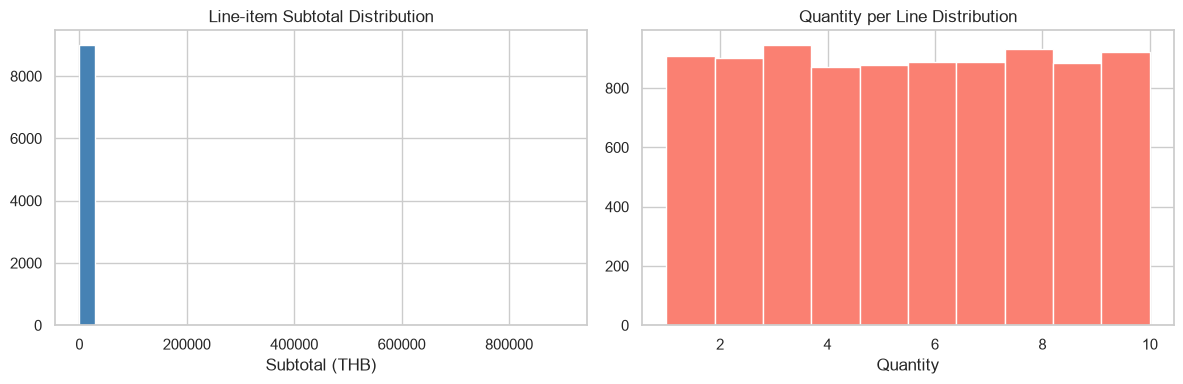

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sales['subtotal'].hist(bins=30, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Line-item Subtotal Distribution')
axes[0].set_xlabel('Subtotal (THB)')

sales['qty'].hist(bins=10, ax=axes[1], color='salmon', edgecolor='white')
axes[1].set_title('Quantity per Line Distribution')
axes[1].set_xlabel('Quantity')

plt.tight_layout()
plt.show()

## 4. Revenue by Category

Where does the money come from?

Revenue by category:
category
Food            6,051,788
Snack           2,765,586
Personal Care   2,312,378
Beverage        2,270,435
Household       1,365,577
Name: subtotal, dtype: float64


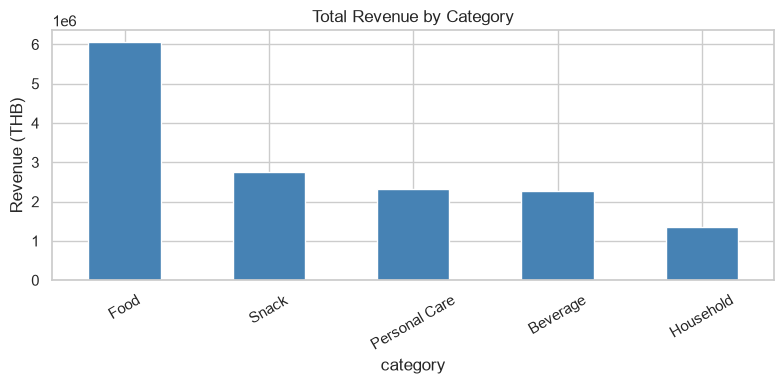

In [6]:
by_cat = sales.groupby('category')['subtotal'].sum().sort_values(ascending=False)
print('Revenue by category:')
print(by_cat)

by_cat.plot(kind='bar', figsize=(8, 4), color='steelblue', edgecolor='white')
plt.title('Total Revenue by Category')
plt.ylabel('Revenue (THB)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 5. Revenue by Brand

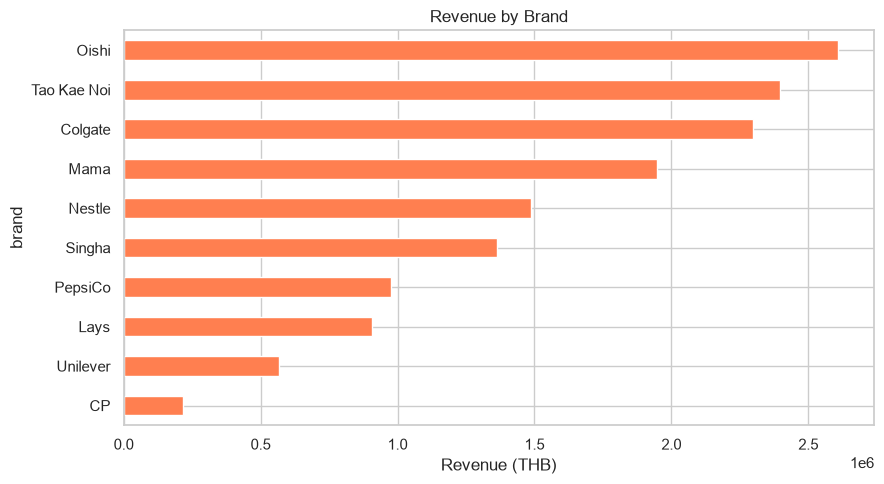

In [7]:
by_brand = sales.groupby('brand')['subtotal'].sum().sort_values(ascending=False)
by_brand.plot(kind='barh', figsize=(9, 5), color='coral')
plt.title('Revenue by Brand')
plt.xlabel('Revenue (THB)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 6. Category × Customer Tier

Revenue split by category and customer sub_tier.

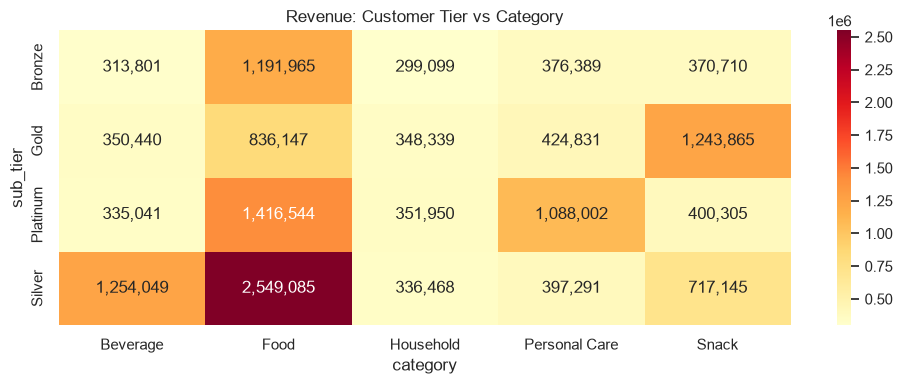

In [8]:
pivot = sales.pivot_table(values='subtotal', index='sub_tier', columns='category',
                          aggfunc='sum', fill_value=0)

plt.figure(figsize=(10, 4))
sns.heatmap(pivot, annot=True, fmt=',.0f', cmap='YlOrRd')
plt.title('Revenue: Customer Tier vs Category')
plt.tight_layout()
plt.show()

## 7. Unit Price vs Quantity

Do pricier items sell in smaller quantities?

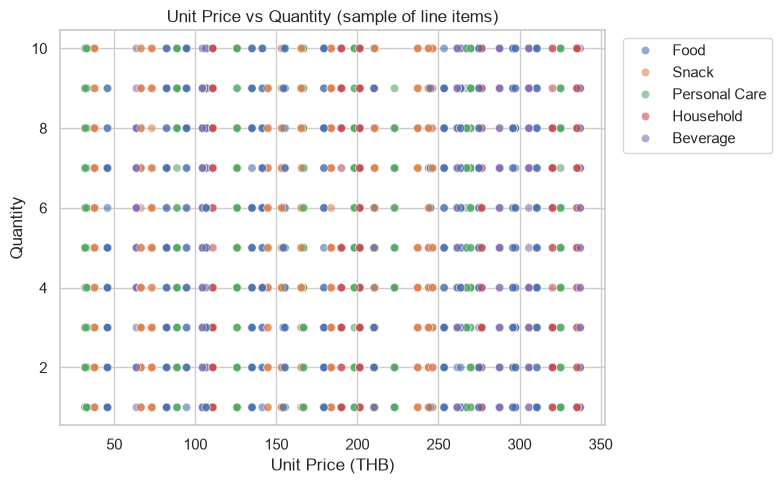

In [9]:
sample = sales.sample(min(2000, len(sales)), random_state=42)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=sample, x='unit_price', y='qty', hue='category', alpha=0.6)
plt.title('Unit Price vs Quantity (sample of line items)')
plt.xlabel('Unit Price (THB)')
plt.ylabel('Quantity')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [10]:
print('Unit price vs quantity correlation:', round(sales['unit_price'].corr(sales['qty']), 3))

Unit price vs quantity correlation: -0.002


## 8. Key Findings

In [11]:
total_rev   = sales['subtotal'].sum()
top_cat     = by_cat.idxmax()
top_brand   = by_brand.idxmax()
top_tier    = sales.groupby('sub_tier')['subtotal'].sum().idxmax()
top_product = sales.groupby('product_name')['subtotal'].sum().idxmax()

print('=' * 52)
print('KEY FINDINGS — QuickMart Sales')
print('=' * 52)
print(f"Line items           : {len(sales):,} across {sales['category'].nunique()} categories")
print(f"Total revenue        : {total_rev:>16,.0f} THB")
print(f"Top category         : {top_cat} ({by_cat[top_cat] / total_rev:.0%} of revenue)")
print(f"Top brand            : {top_brand}")
print(f"Top customer tier    : {top_tier}")
print(f"Star product         : {top_product}")

KEY FINDINGS — QuickMart Sales
Line items           : 9,024 across 5 categories
Total revenue        :       14,765,763 THB
Top category         : Food (41% of revenue)
Top brand            : Oishi
Top customer tier    : Silver
Star product         : Oishi Product 3006


---
## Try It Yourself

1. Which **category** has the highest *average* subtotal per line item?
2. Which **month** had the most revenue? (use the `month` column)
3. How does revenue split across order **status** (completed / processing / cancelled)?
4. Which **brand** has the widest unit-price range?

**Hint:** combine `groupby`, boolean filtering, and `pivot_table`.
